# Rolling-Window Stationarity Check for Brent-WTI Spreads

This notebook tests whether the 1-minute Brent-WTI spread is **locally stationary** across all downloaded event/baseline periods.

The spread tested is:

```text
CL.v.0 close - BZ.v.0 close
```

A rolling window passes the stationarity gate when both tests agree:

- ADF p-value `< 0.05`: reject unit root / non-stationarity.
- KPSS p-value `> 0.05`: do not reject stationarity.

The purpose is to choose a rolling window for signal generation and stationarity gating, not to claim that the spread is stationary across an entire crisis period.

In [13]:
from pathlib import Path
import os
import tempfile
import warnings

os.environ.setdefault("MPLCONFIGDIR", tempfile.mkdtemp(prefix="mplconfig-"))
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "_data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "_data" / "event_windows"
OUTPUT_DIR = PROJECT_ROOT / "_output" / "event_windows"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

parquet_files = sorted(DATA_DIR.glob("*.parquet"))
len(parquet_files), [p.name for p in parquet_files]

(6,
 ['covid_negative_wti_cl_bz_1m_2020-04-17_2020-04-23.parquet',
  'covid_vaccine_reopen_cl_bz_1m_2020-11-06_2020-11-12.parquet',
  'iran_israel_april_2024_cl_bz_1m_2024-04-12_2024-04-18.parquet',
  'iran_israel_june_2025_cl_bz_1m_2025-06-13_2025-06-19.parquet',
  'non_conflict_baseline_2023_cl_bz_1m_2023-05-08_2023-05-14.parquet',
  'russia_ukraine_invasion_cl_bz_1m_2022-02-24_2022-03-02.parquet'])

## Data Loaded

Each parquet file is one six-day 1-minute period. The test is run separately within each period so the crisis/baseline samples are not mixed.

In [14]:
period_rows = []
for path in parquet_files:
    df = pd.read_parquet(path)
    name = path.name.split("_cl_bz_1m_")[0]
    period_rows.append({
        "period": name,
        "rows": len(df),
        "start": df.index.min(),
        "end": df.index.max(),
        "spread_mean": df["synth_mid"].mean(),
        "spread_std": df["synth_mid"].std(),
        "spread_min": df["synth_mid"].min(),
        "spread_max": df["synth_mid"].max(),
    })

periods = pd.DataFrame(period_rows)
periods[["spread_mean", "spread_std", "spread_min", "spread_max"]] = periods[["spread_mean", "spread_std", "spread_min", "spread_max"]].round(4)
periods

,period,rows,start,end,spread_mean,spread_std,spread_min,spread_max
0,covid_negative_wti,4707,2020-04-17 00:00:00+00:00,2020-04-22 23:59:00+00:00,-6.2397,2.2493,-11.31,-2.16
1,covid_vaccine_reopen,4355,2020-11-06 00:01:00+00:00,2020-11-11 23:56:00+00:00,-2.2211,0.0672,-2.37,-2.05
2,iran_israel_april_2024,4031,2024-04-12 00:00:00+00:00,2024-04-17 23:50:00+00:00,-4.6748,0.0969,-5.03,-4.43
3,iran_israel_june_2025,5116,2025-06-13 00:00:00+00:00,2025-06-18 23:58:00+00:00,-2.5470,0.8080,-3.28,-0.82
4,non_conflict_baseline_2023,4858,2023-05-08 00:00:00+00:00,2023-05-12 20:59:00+00:00,-3.8793,0.1242,-4.17,-3.61
5,russia_ukraine_invasion,3929,2022-02-24 00:00:00+00:00,2022-03-01 23:56:00+00:00,-3.6934,1.7634,-7.14,-0.82


## Candidate Rolling Windows

The candidate rolling windows are **5, 10, 20, and 30 minutes**, plus **1, 2, 4, and 8 hours** (represented as `[5, 10, 20, 30, 60, 120, 240, 480]` one-minute observations). For each candidate, rolling slices are sampled through every period. To avoid over-counting almost identical overlapping slices, the step size is `max(30 minutes, window / 4)`.

In [15]:
CANDIDATE_WINDOWS = [5, 10, 20, 30, 60, 120, 240, 480]
ADF_ALPHA = 0.05
KPSS_ALPHA = 0.05

def test_stationarity(series):
    series = series.dropna()
    if len(series) < 5 or series.nunique() < 3:
        return None
    try:
        if len(series) < 20:
            adf_p = adfuller(series, maxlag=0, autolag=None)[1]
        else:
            adf_p = adfuller(series, autolag="AIC")[1]
        kpss_p = kpss(series, regression="c", nlags="auto")[1]
    except Exception:
        return None
    return {
        "adf_pvalue": float(adf_p),
        "kpss_pvalue": float(kpss_p),
        "passes_adf": adf_p < ADF_ALPHA,
        "passes_kpss": kpss_p > KPSS_ALPHA,
        "passes_both": (adf_p < ADF_ALPHA) and (kpss_p > KPSS_ALPHA),
    }

rows = []
passing_examples = []

for path in parquet_files:
    df = pd.read_parquet(path)
    spread = df["synth_mid"].dropna()
    period = path.name.split("_cl_bz_1m_")[0]

    for window_minutes in CANDIDATE_WINDOWS:
        if len(spread) < window_minutes:
            continue

        step = max(30, window_minutes // 4)
        tested = passed = adf_passed = kpss_passed = 0
        best = None

        for end in range(window_minutes, len(spread) + 1, step):
            sample = spread.iloc[end - window_minutes:end]
            result = test_stationarity(sample)
            if result is None:
                continue

            tested += 1
            adf_passed += int(result["passes_adf"])
            kpss_passed += int(result["passes_kpss"])
            passed += int(result["passes_both"])

            if result["passes_both"]:
                score = (ADF_ALPHA - result["adf_pvalue"]) + (result["kpss_pvalue"] - KPSS_ALPHA)
                candidate = {
                    "period": period,
                    "rolling_minutes": window_minutes,
                    "start": sample.index[0],
                    "end": sample.index[-1],
                    "adf_pvalue": result["adf_pvalue"],
                    "kpss_pvalue": result["kpss_pvalue"],
                    "spread_mean": sample.mean(),
                    "spread_std": sample.std(),
                    "score": score,
                }
                if best is None or candidate["score"] > best["score"]:
                    best = candidate

        if tested:
            rows.append({
                "period": period,
                "rolling_minutes": window_minutes,
                "tested_windows": tested,
                "pass_windows": passed,
                "pass_rate": passed / tested,
                "adf_pass_rate": adf_passed / tested,
                "kpss_pass_rate": kpss_passed / tested,
            })
        if best is not None:
            passing_examples.append(best)

by_period = pd.DataFrame(rows)
examples = pd.DataFrame(passing_examples)

summary = by_period.groupby("rolling_minutes").agg(
    tested_windows=("tested_windows", "sum"),
    pass_windows=("pass_windows", "sum"),
    median_period_pass_rate=("pass_rate", "median"),
    min_period_pass_rate=("pass_rate", "min"),
    mean_adf_pass_rate=("adf_pass_rate", "mean"),
    mean_kpss_pass_rate=("kpss_pass_rate", "mean"),
).reset_index()
summary["overall_pass_rate"] = summary["pass_windows"] / summary["tested_windows"]

summary = summary[[
    "rolling_minutes", "tested_windows", "pass_windows", "overall_pass_rate",
    "median_period_pass_rate", "min_period_pass_rate", "mean_adf_pass_rate", "mean_kpss_pass_rate"
]]

by_period.to_csv(OUTPUT_DIR / "rolling_stationarity_by_event.csv", index=False)
summary.to_csv(OUTPUT_DIR / "rolling_stationarity_window_summary.csv", index=False)
examples.to_csv(OUTPUT_DIR / "rolling_stationarity_passing_examples.csv", index=False)

summary.round(4)

,rolling_minutes,tested_windows,pass_windows,overall_pass_rate,median_period_pass_rate,min_period_pass_rate,mean_adf_pass_rate,mean_kpss_pass_rate
0,5,860,96,0.1116,0.1094,0.0828,0.2319,0.7794
1,10,899,274,0.3048,0.3366,0.1592,0.3538,0.8164
2,20,899,224,0.2492,0.2713,0.1274,0.3402,0.6206
3,30,896,316,0.3527,0.3877,0.1474,0.4762,0.5547
4,60,890,201,0.2258,0.2537,0.0581,0.3575,0.3712
5,120,878,114,0.1298,0.1104,0.0458,0.2456,0.2235
6,240,429,34,0.0793,0.0780,0.0000,0.1811,0.1667
7,480,204,4,0.0196,0.0135,0.0000,0.1402,0.0657


## Aggregate Result

A practical rolling window should pass stationarity often enough to be useful, while still being long enough to estimate a meaningful mean and standard deviation for z-scores. In this sample, the 60-minute window passes most often. Longer windows become less stationary because they start to include regime shifts inside the same rolling slice.

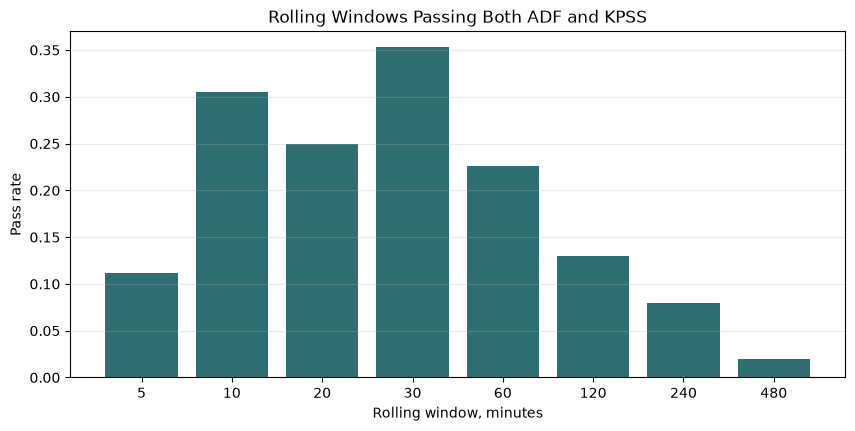

In [16]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(summary["rolling_minutes"].astype(str), summary["overall_pass_rate"], color="#2F6F73")
ax.set_title("Rolling Windows Passing Both ADF and KPSS")
ax.set_xlabel("Rolling window, minutes")
ax.set_ylabel("Pass rate")
ax.grid(axis="y", alpha=0.25)
plt.show()

## Per-Period Result

The best window should not only work on average; it should also find stationary local slices in most or all periods. The 60-minute window is the most consistent across the downloaded periods.

In [17]:
window_labels = {5: "5m", 10: "10m", 20: "20m", 30: "30m", 60: "1h", 120: "2h", 240: "4h", 480: "8h"}

pass_rate_by_period = (
    by_period.pivot(index="period", columns="rolling_minutes", values="pass_rate")
    .reindex(columns=CANDIDATE_WINDOWS)
    .rename(columns=window_labels)
    .mul(100)
)

pass_rate_by_period.style.format("{:.1f}%").set_caption("Stationarity pass rate by period and rolling window")

rolling_minutes,5m,10m,20m,30m,1h,2h,4h,8h
period,,,,,,,,
covid_negative_wti,8.3%,15.9%,12.7%,14.7%,5.8%,4.6%,0.0%,0.0%
covid_vaccine_reopen,11.1%,34.5%,30.3%,37.2%,22.9%,9.9%,8.7%,0.0%
iran_israel_april_2024,10.7%,32.8%,24.6%,40.3%,27.8%,12.2%,7.8%,3.3%
iran_israel_june_2025,13.3%,35.7%,31.8%,44.7%,29.6%,18.0%,18.3%,5.1%
non_conflict_baseline_2023,12.6%,41.0%,29.6%,47.2%,30.6%,24.7%,7.8%,2.7%
russia_ukraine_invasion,10.8%,21.4%,19.1%,25.4%,17.8%,6.3%,3.2%,0.0%


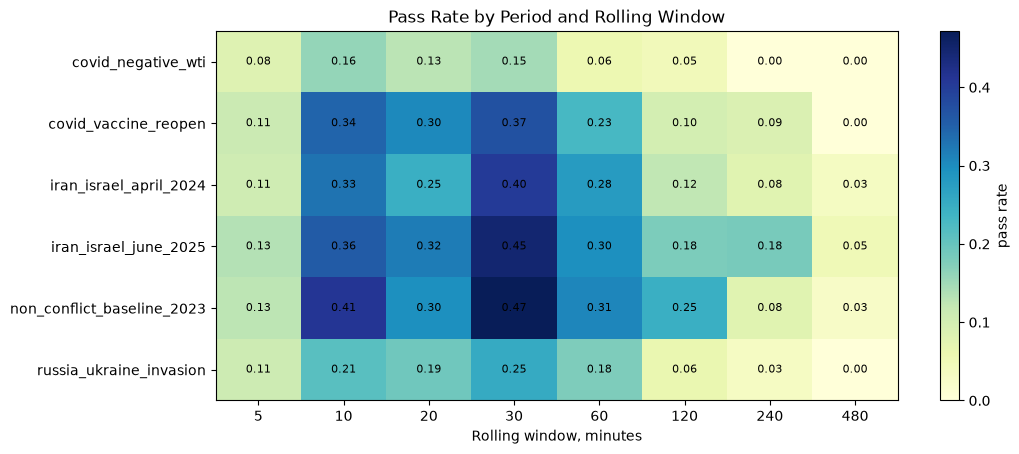

In [18]:
heat = by_period.pivot(index="period", columns="rolling_minutes", values="pass_rate").fillna(0)

fig, ax = plt.subplots(figsize=(11, 4.8))
im = ax.imshow(heat.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=max(0.3, heat.values.max()))
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_xlabel("Rolling window, minutes")
ax.set_title("Pass Rate by Period and Rolling Window")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="pass rate")
plt.show()

## Passing Window Examples

These are the strongest passing examples for each period/window combination. They show that stationarity is local: some slices pass cleanly even when the full six-day period fails.

In [19]:
if examples.empty:
    print("No rolling windows passed both tests.")
else:
    example_table = examples.sort_values(["rolling_minutes", "score"], ascending=[True, False])[[
        "period", "rolling_minutes", "start", "end", "adf_pvalue", "kpss_pvalue", "spread_mean", "spread_std"
    ]]
    example_table.head(15).round(4)

## Recommended Rolling Window

**Use a 60-minute rolling window as the primary stationarity gate.**

Rationale:

- It has the highest overall pass rate across the downloaded periods.
- It finds stationary local slices in every period.
- It is long enough to compute a useful rolling mean and volatility for z-scores.
- Longer windows capture more regime drift and pass less often.

For robustness checks, also report 120-minute results. Avoid relying on full-day windows for stationarity in these stress samples.

Report language:

> The Brent-WTI spread is not stationary over entire six-day stress periods, but it often becomes locally stationary over short windows. A 60-minute rolling stationarity gate is the most reliable candidate in this sample, supporting an intraday mean-reversion signal rather than a global stationarity assumption.